# Submission Akhir BMLP: Clustering Transaksi Finansial

Segmentasi transaksi finansial dengan K-Means. Target klasifikasi lanjutan berasal dari kolom `Target` hasil clustering notebook ini.

In [1]:
# Import library
import sys
import setuptools._distutils as _du
import setuptools._distutils.version as _duv
sys.modules.setdefault("distutils", _du)
sys.modules.setdefault("distutils.version", _duv)

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
KMeans._estimator_type = "clusterer"
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from yellowbrick.cluster import KElbowVisualizer

%matplotlib inline
print("pandas:", pd.__version__)
import sklearn
print("scikit-learn:", sklearn.__version__)


pandas: 3.0.6
scikit-learn: 1.9.1


In [2]:
# Load data
df = pd.read_csv("data/fraud_transactions.csv")
print("Shape:", df.shape)
print("Kolom:", df.columns.tolist())


Shape: (3045, 17)
Kolom: ['TransactionID', 'AccountID', 'DeviceID', 'IPAddress', 'MerchantID', 'TransactionDate', 'TransactionAmount', 'AccountAgeDays', 'NumTransactionsLast7D', 'AvgTransactionAmount7D', 'TransactionHour', 'BalanceBefore', 'BalanceAfter', 'TransactionType', 'MerchantCategory', 'DeviceType', 'Location']


In [3]:
# Tampilkan 5 baris pertama dengan function head.
df.head()


,TransactionID,AccountID,DeviceID,IPAddress,MerchantID,TransactionDate,TransactionAmount,AccountAgeDays,NumTransactionsLast7D,AvgTransactionAmount7D,TransactionHour,BalanceBefore,BalanceAfter,TransactionType,MerchantCategory,DeviceType,Location
0,TXN001287,ACC00007,DEV00445,7.128.125.58,MER0137,2024-11-01 21:47:00,24.70,850,16,18.25,21,9578.67,9553.97,Purchase,Food,Mobile,Medan
1,TXN000643,ACC00500,DEV00073,235.148.229.91,MER0055,2024-01-04 13:42:00,11.60,681,15,8.25,13,3178.36,3166.76,Payment,Grocery,Mobile,Jakarta
2,TXN001147,ACC00601,DEV00106,108.61.3.198,MER0039,2024-02-17 02:49:00,221.83,316,5,169.53,2,1668.02,1446.19,Transfer,Fashion,Mobile,Bandung
3,TXN001279,ACC00555,DEV00069,229.18.149.207,MER0126,2024-03-13 03:48:00,396.46,51,3,373.11,3,5947.21,5550.75,Transfer,Travel,Mobile,Medan
4,TXN001940,ACC00019,DEV00461,18.5.53.72,MER0154,2024-05-22 08:11:00,15.24,1076,8,15.15,8,6825.49,6810.25,Payment,Grocery,Desktop,Bandung


In [4]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3045 entries, 0 to 3044
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   TransactionID           3045 non-null   str    
 1   AccountID               3045 non-null   str    
 2   DeviceID                3045 non-null   str    
 3   IPAddress               3045 non-null   str    
 4   MerchantID              3045 non-null   str    
 5   TransactionDate         3045 non-null   str    
 6   TransactionAmount       3045 non-null   float64
 7   AccountAgeDays          3045 non-null   int64  
 8   NumTransactionsLast7D   3045 non-null   int64  
 9   AvgTransactionAmount7D  2982 non-null   float64
 10  TransactionHour         3045 non-null   int64  
 11  BalanceBefore           3045 non-null   float64
 12  BalanceAfter            3045 non-null   float64
 13  TransactionType         3045 non-null   str    
 14  MerchantCategory        2985 non-null   str    
 15

In [5]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe
print("Deskriptif numerik:")
display(df.describe().T)
print("Deskriptif kategorikal:")
display(df.describe(include="object").T)


Deskriptif numerik:


,count,mean,std,min,25%,50%,75%,max
TransactionAmount,3045.0,295.205468,453.919694,6.26,32.7900,97.500,345.4700,4285.90
AccountAgeDays,3045.0,989.796388,829.839867,1.00,261.0000,812.000,1477.0000,2995.00
NumTransactionsLast7D,3045.0,7.601970,5.126763,0.00,3.0000,7.000,12.0000,27.00
AvgTransactionAmount7D,2982.0,265.177257,414.238991,4.39,29.3025,89.985,302.1475,4342.38
TransactionHour,3045.0,11.031199,6.784704,0.00,5.0000,11.000,17.0000,23.00
BalanceBefore,3045.0,6784.764631,6745.157756,303.11,2857.5300,4803.020,8279.3000,86793.06
BalanceAfter,3045.0,6489.559163,6757.356617,-1855.50,2538.3800,4537.960,7967.5000,86758.19


Deskriptif kategorikal:


C:\Users\USER\AppData\Local\Temp\ipykernel_30788\1553509699.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object").T)


,count,unique,top,freq
TransactionID,3045,3000,TXN000638,2
AccountID,3045,778,ACC00480,11
DeviceID,3045,499,DEV00158,13
IPAddress,3045,3000,70.61.216.68,2
MerchantID,3045,199,MER0062,28
TransactionDate,3045,2989,2024-08-11 08:11:00,2
TransactionType,3045,4,Purchase,1092
MerchantCategory,2985,5,Travel,787
DeviceType,3045,3,Mobile,1962
Location,3045,5,Surabaya,630


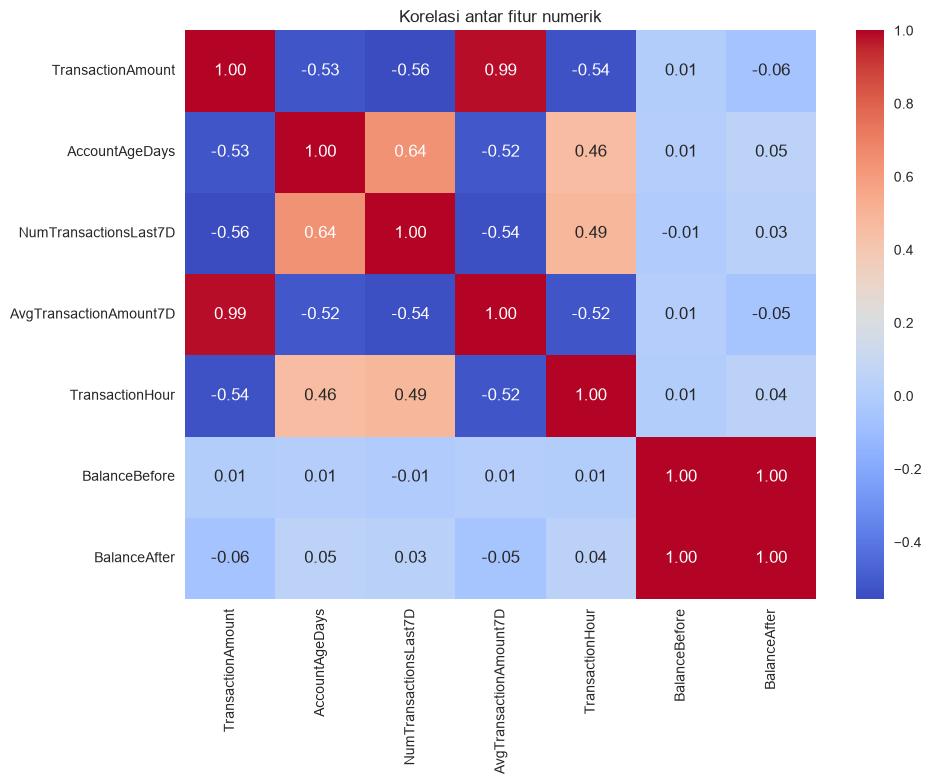

In [6]:
# Menampilkan korelasi antar fitur (Opsional Skilled 1)
num_df = df.select_dtypes(include="number")
plt.figure(figsize=(10, 8))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Korelasi antar fitur numerik")
plt.tight_layout()
plt.show()


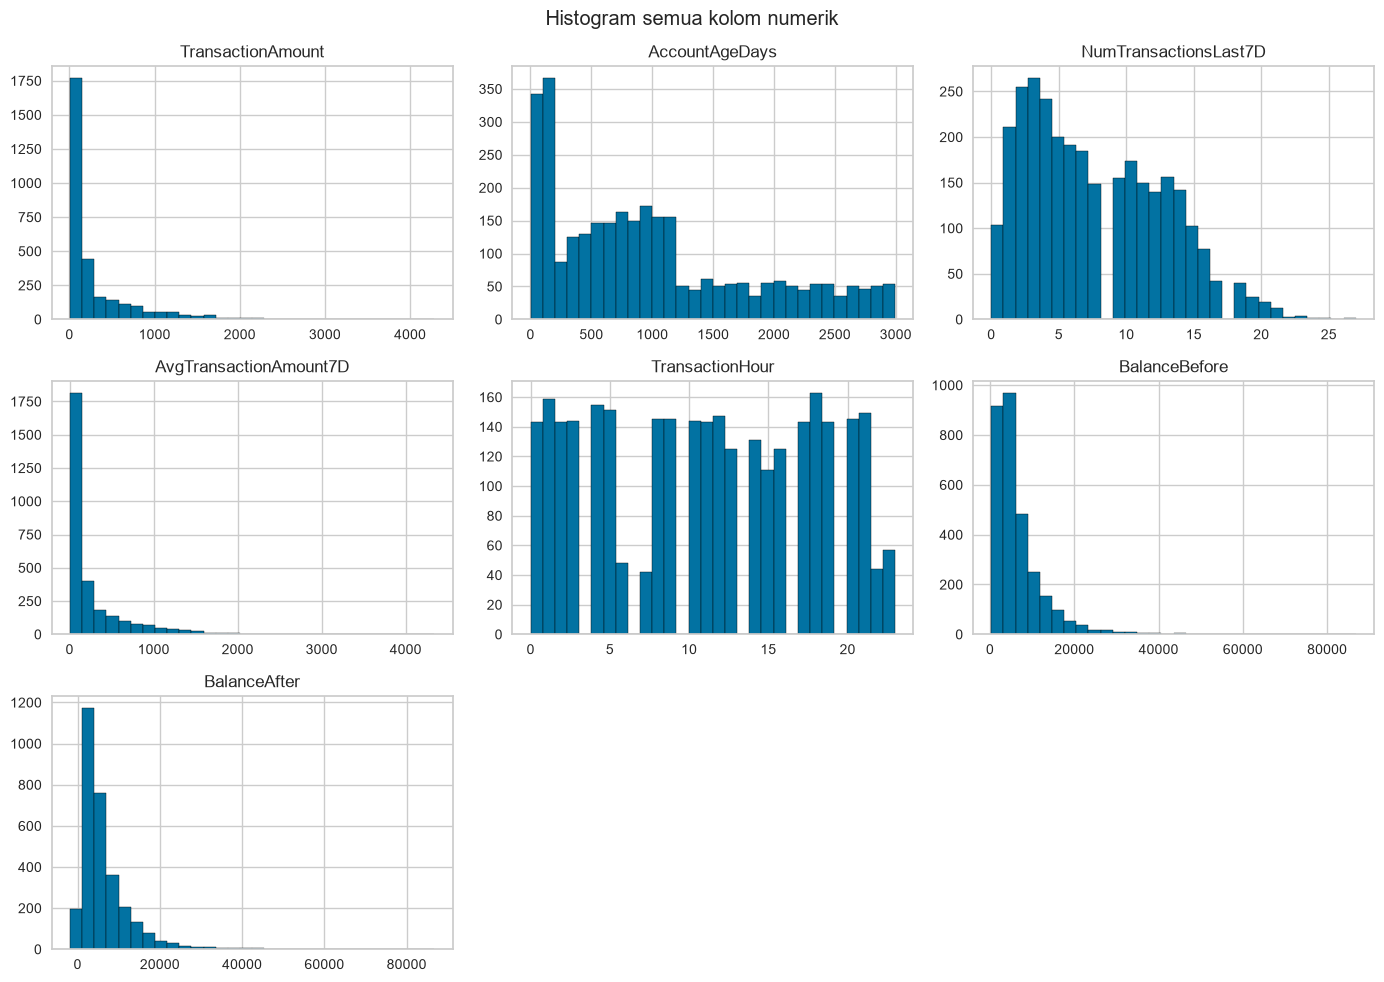

In [7]:
# Menampilkan histogram untuk semua kolom numerik (Opsional Skilled 1)
num_cols_raw = df.select_dtypes(include="number").columns.tolist()
df[num_cols_raw].hist(figsize=(14, 10), bins=30, edgecolor="black")
plt.suptitle("Histogram semua kolom numerik")
plt.tight_layout()
plt.show()


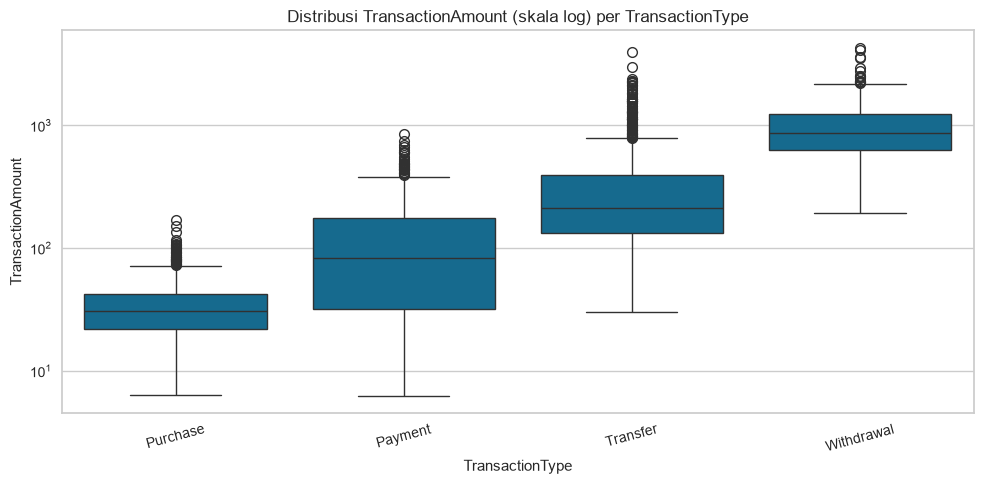

Interpretasi singkat: Withdrawal dan Transfer cenderung memiliki nilai lebih besar dibanding Purchase.


In [8]:
# Visualisasi yang lebih informatif (Opsional Advanced 1)
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="TransactionType", y="TransactionAmount")
plt.yscale("log")
plt.title("Distribusi TransactionAmount (skala log) per TransactionType")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
print("Interpretasi singkat: Withdrawal dan Transfer cenderung memiliki nilai lebih besar dibanding Purchase.")


In [9]:
# Mengecek dataset menggunakan isnull().sum()
print(df.isnull().sum())
print("Total missing:", int(df.isnull().sum().sum()))


TransactionID              0
AccountID                  0
DeviceID                   0
IPAddress                  0
MerchantID                 0
TransactionDate            0
TransactionAmount          0
AccountAgeDays             0
NumTransactionsLast7D      0
AvgTransactionAmount7D    63
TransactionHour            0
BalanceBefore              0
BalanceAfter               0
TransactionType            0
MerchantCategory          60
DeviceType                 0
Location                   0
dtype: int64
Total missing: 123


In [10]:
# Mengecek dataset menggunakan duplicated().sum()
print("Jumlah baris duplikat:", int(df.duplicated().sum()))


Jumlah baris duplikat: 45


In [11]:
# Menangani data yang hilang.
print("Shape sebelum dropna:", df.shape)
df_clean = df.dropna().reset_index(drop=True)
print("Shape setelah dropna:", df_clean.shape)
print("Baris dibuang:", df.shape[0] - df_clean.shape[0])


Shape sebelum dropna: (3045, 17)
Shape setelah dropna: (2922, 17)
Baris dibuang: 123


In [12]:
# Menghapus data duplikat.
print("Shape sebelum drop_duplicates:", df_clean.shape)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Shape setelah drop_duplicates:", df_clean.shape)
print("Sisa duplikat:", int(df_clean.duplicated().sum()))


Shape sebelum drop_duplicates: (2922, 17)
Shape setelah drop_duplicates: (2880, 17)
Sisa duplikat: 0


In [13]:
# Melakukan drop pada kolom yang memiliki keterangan Date, id, dan IP Address
drop_cols = ["TransactionID", "AccountID", "DeviceID", "IPAddress", "MerchantID", "TransactionDate"]
df_model = df_clean.drop(columns=drop_cols)
print("Kolom di-drop:", drop_cols)
print("Kolom tersisa:", df_model.columns.tolist())
print("Shape:", df_model.shape)


Kolom di-drop: ['TransactionID', 'AccountID', 'DeviceID', 'IPAddress', 'MerchantID', 'TransactionDate']
Kolom tersisa: ['TransactionAmount', 'AccountAgeDays', 'NumTransactionsLast7D', 'AvgTransactionAmount7D', 'TransactionHour', 'BalanceBefore', 'BalanceAfter', 'TransactionType', 'MerchantCategory', 'DeviceType', 'Location']
Shape: (2880, 11)


In [14]:
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal.
cat_cols = df_model.select_dtypes(include="object").columns.tolist()
print("Fitur kategorikal:", cat_cols)
encoders = {}
df_encoded = df_model.copy()
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    encoders[col] = le
    print(col, "->", list(le.classes_))
df_encoded.head()


Fitur kategorikal: ['TransactionType', 'MerchantCategory', 'DeviceType', 'Location']
TransactionType -> ['Payment', 'Purchase', 'Transfer', 'Withdrawal']
MerchantCategory -> ['Electronics', 'Fashion', 'Food', 'Grocery', 'Travel']
DeviceType -> ['Desktop', 'Mobile', 'Tablet']
Location -> ['Bandung', 'Denpasar', 'Jakarta', 'Medan', 'Surabaya']


C:\Users\USER\AppData\Local\Temp\ipykernel_30788\4259205983.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include="object").columns.tolist()


,TransactionAmount,AccountAgeDays,NumTransactionsLast7D,AvgTransactionAmount7D,TransactionHour,BalanceBefore,BalanceAfter,TransactionType,MerchantCategory,DeviceType,Location
0,24.70,850,16,18.25,21,9578.67,9553.97,1,2,1,3
1,11.60,681,15,8.25,13,3178.36,3166.76,0,3,1,2
2,221.83,316,5,169.53,2,1668.02,1446.19,2,1,1,0
3,396.46,51,3,373.11,3,5947.21,5550.75,2,4,1,3
4,15.24,1076,8,15.15,8,6825.49,6810.25,0,3,0,0


In [15]:
# Last checking gunakan columns.tolist() untuk checking seluruh fitur yang ada.
print(df_encoded.columns.tolist())
print("Shape:", df_encoded.shape)
print("Missing:", int(df_encoded.isnull().sum().sum()))


['TransactionAmount', 'AccountAgeDays', 'NumTransactionsLast7D', 'AvgTransactionAmount7D', 'TransactionHour', 'BalanceBefore', 'BalanceAfter', 'TransactionType', 'MerchantCategory', 'DeviceType', 'Location']
Shape: (2880, 11)
Missing: 0


In [16]:
# Melakukan Handling Outlier Data menggunakan metode drop.
num_cols = [c for c in df_encoded.select_dtypes(include="number").columns.tolist() if c not in encoders]
print("Fitur numerik (non-kategorikal):", num_cols)
keep_mask = pd.Series(True, index=df_encoded.index)
for col in num_cols:
    q1 = df_encoded[col].quantile(0.25)
    q3 = df_encoded[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    before = int((~keep_mask).sum())
    keep_mask = keep_mask & df_encoded[col].between(lower, upper)
    print(col + ": batas [" + str(round(lower, 2)) + ", " + str(round(upper, 2)) + "], kumulatif dibuang: " + str(int((~keep_mask).sum())))
print("Shape sebelum drop outlier:", df_encoded.shape)
df_no_outlier = df_encoded[keep_mask].reset_index(drop=True)
print("Shape setelah drop outlier:", df_no_outlier.shape)


Fitur numerik (non-kategorikal): ['TransactionAmount', 'AccountAgeDays', 'NumTransactionsLast7D', 'AvgTransactionAmount7D', 'TransactionHour', 'BalanceBefore', 'BalanceAfter']
TransactionAmount: batas [-428.38, 801.17], kumulatif dibuang: 326
AccountAgeDays: batas [-1564.62, 3326.38], kumulatif dibuang: 326
NumTransactionsLast7D: batas [-10.5, 25.5], kumulatif dibuang: 327
AvgTransactionAmount7D: batas [-376.01, 704.54], kumulatif dibuang: 355
TransactionHour: batas [-13.0, 35.0], kumulatif dibuang: 355
BalanceBefore: batas [-5277.99, 16476.92], kumulatif dibuang: 515
BalanceAfter: batas [-5595.41, 16158.41], kumulatif dibuang: 522
Shape sebelum drop outlier: (2880, 11)
Shape setelah drop outlier: (2358, 11)


In [17]:
# Melakukan feature scaling menggunakan StandardScaler() untuk fitur numerik.
num_cols = [c for c in df_no_outlier.select_dtypes(include="number").columns.tolist() if c not in encoders]
scaler = StandardScaler()
df_scaled = df_no_outlier.copy()
df_scaled[num_cols] = scaler.fit_transform(df_no_outlier[num_cols])
print("Mean setelah scaling (mendekati 0):")
print(df_scaled[num_cols].mean().round(4).to_dict())
df_scaled.head()


Mean setelah scaling (mendekati 0):
{'TransactionAmount': -0.0, 'AccountAgeDays': -0.0, 'NumTransactionsLast7D': -0.0, 'AvgTransactionAmount7D': 0.0, 'TransactionHour': -0.0, 'BalanceBefore': -0.0, 'BalanceAfter': 0.0}


,TransactionAmount,AccountAgeDays,NumTransactionsLast7D,AvgTransactionAmount7D,TransactionHour,BalanceBefore,BalanceAfter,TransactionType,MerchantCategory,DeviceType,Location
0,-0.712759,-0.331391,1.529329,-0.740189,1.383061,1.153266,1.187845,1,2,1,3
1,-0.785220,-0.538882,1.327834,-0.802968,0.129454,-0.636996,-0.596553,0,3,1,2
2,0.377638,-0.987014,-0.687117,0.209539,-1.594255,-1.059461,-1.077230,2,1,1,0
3,1.343579,-1.312369,-1.090107,1.487604,-1.437554,0.137492,0.069463,2,4,1,3
4,-0.765086,-0.053918,-0.082632,-0.759650,-0.654050,0.383160,0.421330,0,3,0,0


In [18]:
# Melakukan binning data berdasarkan kondisi rentang nilai pada fitur numerik,
df_binned = df_scaled.copy()
df_binned["AmountBin"] = pd.cut(
    df_binned["TransactionAmount"],
    bins=4,
    labels=["Rendah", "Sedang", "Tinggi", "Sangat Tinggi"]
)
print(df_binned["AmountBin"].value_counts())
le_bin = LabelEncoder()
df_binned["AmountBin"] = le_bin.fit_transform(df_binned["AmountBin"].astype(str))
print("Mapping bin:", dict(zip(le_bin.classes_, le_bin.transform(le_bin.classes_))))
df_binned.head()


AmountBin
Rendah           1762
Sedang            316
Tinggi            170
Sangat Tinggi     110
Name: count, dtype: int64
Mapping bin: {'Rendah': np.int64(0), 'Sangat Tinggi': np.int64(1), 'Sedang': np.int64(2), 'Tinggi': np.int64(3)}


,TransactionAmount,AccountAgeDays,NumTransactionsLast7D,AvgTransactionAmount7D,TransactionHour,BalanceBefore,BalanceAfter,TransactionType,MerchantCategory,DeviceType,Location,AmountBin
0,-0.712759,-0.331391,1.529329,-0.740189,1.383061,1.153266,1.187845,1,2,1,3,0
1,-0.785220,-0.538882,1.327834,-0.802968,0.129454,-0.636996,-0.596553,0,3,1,2,0
2,0.377638,-0.987014,-0.687117,0.209539,-1.594255,-1.059461,-1.077230,2,1,1,0,2
3,1.343579,-1.312369,-1.090107,1.487604,-1.437554,0.137492,0.069463,2,4,1,3,2
4,-0.765086,-0.053918,-0.082632,-0.759650,-0.654050,0.383160,0.421330,0,3,0,0,0


In [19]:
# Gunakan describe untuk memastikan proses clustering menggunakan dataset hasil preprocessing
print("Shape dataset final preprocessing:", df_binned.shape)
print("Kolom:", df_binned.columns.tolist())
display(df_binned.describe().T)


Shape dataset final preprocessing: (2358, 12)
Kolom: ['TransactionAmount', 'AccountAgeDays', 'NumTransactionsLast7D', 'AvgTransactionAmount7D', 'TransactionHour', 'BalanceBefore', 'BalanceAfter', 'TransactionType', 'MerchantCategory', 'DeviceType', 'Location', 'AmountBin']


,count,mean,std,min,25%,50%,75%,max
TransactionAmount,2358.0,-6.026656e-17,1.000212,-0.814370,-0.683263,-0.489403,0.288458,3.570061
AccountAgeDays,2358.0,-3.766660e-17,1.000212,-1.373757,-0.775839,-0.223962,0.676291,2.302149
NumTransactionsLast7D,2358.0,-1.913463e-16,1.000212,-1.694592,-0.888612,-0.082632,0.723349,3.342784
AvgTransactionAmount7D,2358.0,8.738651e-17,1.000212,-0.816403,-0.687454,-0.482290,0.285628,3.562968
TransactionHour,2358.0,-3.314661e-17,1.000212,-1.907657,-0.654050,-0.027247,0.912959,1.696463
BalanceBefore,2358.0,-1.649797e-16,1.000212,-1.409966,-0.754418,-0.260778,0.487052,3.005876
BalanceAfter,2358.0,6.666988e-17,1.000212,-1.471813,-0.762882,-0.260640,0.489756,3.030855
TransactionType,2358.0,1.213740e+00,0.874441,0.000000,1.000000,1.000000,2.000000,3.000000
MerchantCategory,2358.0,2.166667e+00,1.425494,0.000000,1.000000,2.000000,3.000000,4.000000
DeviceType,2358.0,7.820187e-01,0.529149,0.000000,0.000000,1.000000,1.000000,2.000000


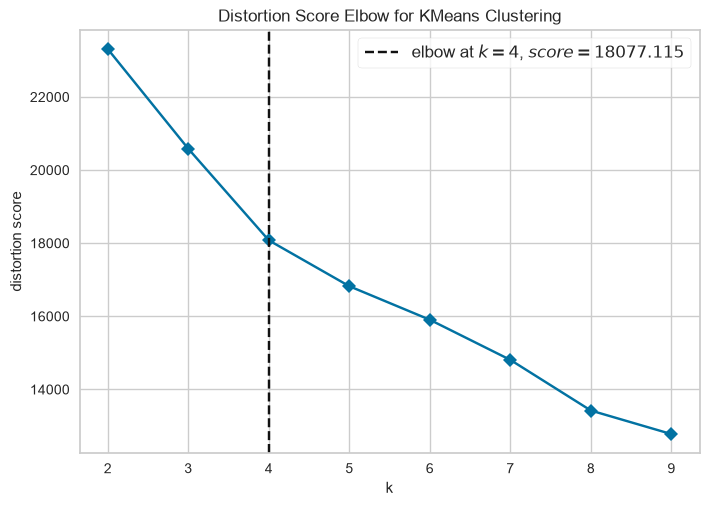

Nilai elbow terdeteksi: 4


In [20]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()
X = df_binned.values
elbow_model = KMeans(random_state=42)
visualizer = KElbowVisualizer(elbow_model, k=(2, 10), metric="distortion", timings=False)
visualizer.fit(X)
visualizer.show()
print("Nilai elbow terdeteksi:", visualizer.elbow_value_)


In [21]:
# Menggunakan algoritma K-Means Clustering
k_optimal = visualizer.elbow_value_
if k_optimal is None:
    k_optimal = 4
k_optimal = int(k_optimal)
print("Jumlah cluster terbaik:", k_optimal)
kmeans = KMeans(n_clusters=k_optimal, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X)
print("Distribusi anggota tiap cluster:")
print(pd.Series(clusters, name="cluster").value_counts().sort_index())
print("Inertia:", round(kmeans.inertia_, 2))


Jumlah cluster terbaik: 4
Distribusi anggota tiap cluster:
cluster
0    860
1    312
2    635
3    551
Name: count, dtype: int64
Inertia: 18070.05


In [22]:
# Menyimpan model menggunakan joblib
joblib.dump(kmeans, "model_clustering.h5")
print("Model tersimpan: model_clustering.h5")
print("Tipe objek:", type(joblib.load("model_clustering.h5")))


Model tersimpan: model_clustering.h5
Tipe objek: <class 'sklearn.cluster._kmeans.KMeans'>


In [23]:
# Menghitung dan menampilkan nilai Silhouette Score.
score = silhouette_score(X, clusters)
print("Silhouette Score:", round(score, 4))


Silhouette Score: 0.1766


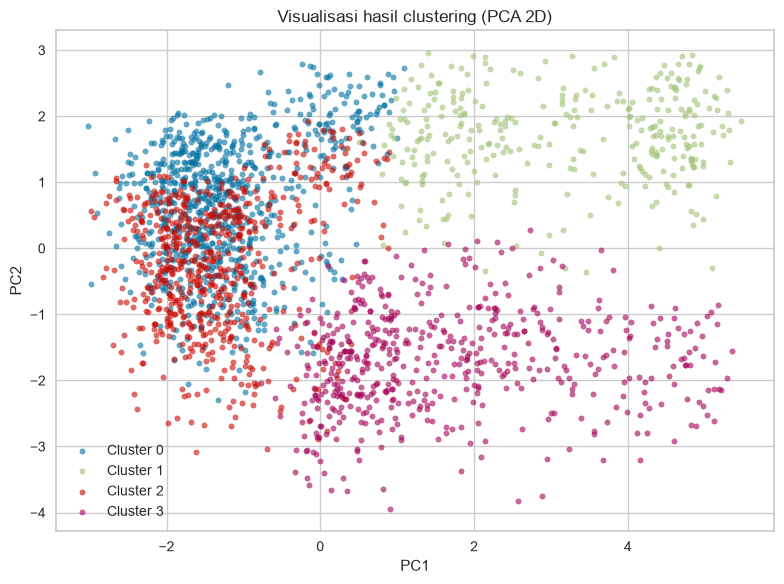

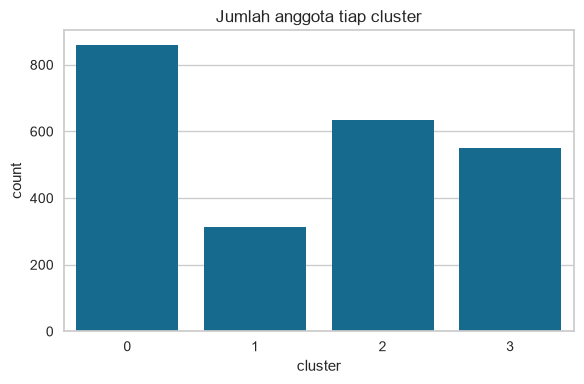

In [24]:
# Membuat visualisasi hasil clustering
pca_viz = PCA(n_components=2, random_state=42)
X_2d = pca_viz.fit_transform(X)
plt.figure(figsize=(8, 6))
for cl in sorted(pd.Series(clusters).unique()):
    pts = X_2d[clusters == cl]
    plt.scatter(pts[:, 0], pts[:, 1], label="Cluster " + str(cl), alpha=0.6, s=15)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Visualisasi hasil clustering (PCA 2D)")
plt.legend()
plt.tight_layout()
plt.show()
plt.figure(figsize=(6, 4))
sns.countplot(x=pd.Series(clusters, name="cluster"))
plt.title("Jumlah anggota tiap cluster")
plt.tight_layout()
plt.show()


In [25]:
# Membangun model menggunakan PCA.
model = PCA(n_components=2, random_state=42)
X_pca = model.fit_transform(X)
print("Explained variance ratio:", model.explained_variance_ratio_.round(4))
print("Total variance 2 komponen:", round(float(model.explained_variance_ratio_.sum()), 4))
print("Shape hasil PCA:", X_pca.shape)


Explained variance ratio: [0.3196 0.1575]
Total variance 2 komponen: 0.477
Shape hasil PCA: (2358, 2)


In [26]:
# Simpan model PCA sebagai perbandingan dengan menjalankan cell code ini joblib.dump(model,"PCA_model_clustering.h5")
joblib.dump(model,"PCA_model_clustering.h5")
print("Model PCA tersimpan: PCA_model_clustering.h5")
print("Tipe objek:", type(joblib.load("PCA_model_clustering.h5")))


Model PCA tersimpan: PCA_model_clustering.h5
Tipe objek: <class 'sklearn.decomposition._pca.PCA'>


In [27]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik.
df_clustered = df_binned.copy()
df_clustered["Target"] = clusters
num_features = df_binned.select_dtypes(include="number").columns.tolist()
agg = df_clustered.groupby("Target")[num_features].agg(["mean", "min", "max"]).round(2)
display(agg)
print("Ukuran tiap cluster:")
print(df_clustered["Target"].value_counts().sort_index())


TransactionAmount             AccountAgeDays              \
                    mean   min   max           mean   min   max   
Target                                                            
0                  -0.57 -0.81  0.72           0.47 -1.26  2.30   
1                   1.56 -0.23  3.57          -0.88 -1.37  0.09   
2                  -0.56 -0.81  0.72           0.39 -1.23  2.30   
3                   0.64 -0.67  3.55          -0.68 -1.37  0.10   

       NumTransactionsLast7D             AvgTransactionAmount7D  ...  \
                        mean   min   max                   mean  ...   
Target                                                           ...   
0                       0.52 -1.69  3.34                  -0.57  ...   
1                      -1.00 -1.69  0.72                   1.54  ...   
2                       0.50 -1.69  3.14                  -0.56  ...   
3                      -0.82 -1.69  0.52                   0.65  ...   

       MerchantCategory DeviceType         Location         AmountBin          
                    max       mean min max     mean min max      mean min max  
Target                                                                         
0                     4       0.84   0   2     1.03   0   2      0.01   0   2  
1                     4       0.59   0   2     1.89   0   4      1.99   0   3  
2                     4       0.84   0   2     3.53   3   4      0.01   0   2  
3                     1       0.73   0   2     1.93   0   4      1.12   0   3  

[4 rows x 36 columns]

Ukuran tiap cluster:
Target
0    860
1    312
2    635
3    551
Name: count, dtype: int64


### Penjelasan karakteristik tiap cluster

| Cluster | Ukuran | Ciri utama | Interpretasi |
|---|---|---|---|
| **0** | 860 | Amount kecil (mean ~51, maks ~284), akun lama (~1504 hari), frekuensi tinggi (~11 trx/7 hari), jam siang (~14). Modus: Purchase, Grocery, Mobile, Jakarta, bin Rendah | **Pelanggan reguler loyal Jakarta**: transaksi kecil dan rutin dari akun mapan di jam wajar. Segmen sehat terbesar |
| **1** | 312 | Amount besar (mean ~436, 112-799), akun muda (~401 hari, min 1 hari), frekuensi rendah (~3,4 trx/7 hari), jam pagi (~6-7). Modus: Transfer, Travel, Desktop, Jakarta, bin Sedang | **Segmen berisiko atau anomali**: nilai besar dari akun muda yang jarang bertransaksi di jam tidak biasa. Prioritas monitoring fraud |
| **2** | 635 | Amount kecil (mean ~53), akun lama (~1434 hari), frekuensi tinggi (~10,9 trx/7 hari), jam siang (~14). Modus: Purchase, Grocery, Mobile, Surabaya, bin Rendah | **Pelanggan reguler Surabaya**: profil mirip cluster 0 dengan wilayah berbeda. Segmen sehat, peluang retensi |
| **3** | 551 | Amount sedang (mean ~270, 32-795), akun sedang (~565 hari), frekuensi sedang (~4,4 trx/7 hari), jam pagi-siang (~9-10). Modus: Transfer, Electronics, Mobile, Medan, bin Rendah | **Segmen menengah**: nilai dan frekuensi moderat, kandidat upsell dan cross-sell dengan monitoring standar |

Catatan: angka label cluster bersifat arbitrer dari K-Means. Pemaknaan didasarkan pada profil agregat mean, min, dan max, bukan pada angka labelnya.

In [28]:
# Pastikan nama kolom clustering sudah diubah menjadi Target
print(df_clustered.columns.tolist())
assert "Target" in df_clustered.columns
print("Jumlah label unik Target:", df_clustered["Target"].nunique())
print(df_clustered["Target"].value_counts().sort_index())


['TransactionAmount', 'AccountAgeDays', 'NumTransactionsLast7D', 'AvgTransactionAmount7D', 'TransactionHour', 'BalanceBefore', 'BalanceAfter', 'TransactionType', 'MerchantCategory', 'DeviceType', 'Location', 'AmountBin', 'Target']
Jumlah label unik Target: 4
Target
0    860
1    312
2    635
3    551
Name: count, dtype: int64


In [29]:
# Simpan Data
df_clustered.to_csv("data_clustering.csv", index=False)
print("Tersimpan: data_clustering.csv", df_clustered.shape)
print("Kolom:", df_clustered.columns.tolist())


Tersimpan: data_clustering.csv (2358, 13)
Kolom: ['TransactionAmount', 'AccountAgeDays', 'NumTransactionsLast7D', 'AvgTransactionAmount7D', 'TransactionHour', 'BalanceBefore', 'BalanceAfter', 'TransactionType', 'MerchantCategory', 'DeviceType', 'Location', 'AmountBin', 'Target']


In [30]:
# inverse dataset ke rentang normal untuk numerikal
num_cols = [c for c in df_clustered.select_dtypes(include="number").columns.tolist() if c not in encoders and c not in ("Target", "AmountBin")]
df_inverse = df_clustered.copy()
df_inverse[num_cols] = scaler.inverse_transform(df_clustered[num_cols])
print("Kolom numerik di-inverse:", num_cols)
df_inverse[num_cols].head()


Kolom numerik di-inverse: ['TransactionAmount', 'AccountAgeDays', 'NumTransactionsLast7D', 'AvgTransactionAmount7D', 'TransactionHour', 'BalanceBefore', 'BalanceAfter']


,TransactionAmount,AccountAgeDays,NumTransactionsLast7D,AvgTransactionAmount7D,TransactionHour,BalanceBefore,BalanceAfter
0,24.70,850.0,16.0,18.25,21.0,9578.67,9553.97
1,11.60,681.0,15.0,8.25,13.0,3178.36,3166.76
2,221.83,316.0,5.0,169.53,2.0,1668.02,1446.19
3,396.46,51.0,3.0,373.11,3.0,5947.21,5550.75
4,15.24,1076.0,8.0,15.15,8.0,6825.49,6810.25


In [31]:
# inverse dataset yang sudah diencode ke kategori aslinya.
for col, le in encoders.items():
    df_inverse[col] = le.inverse_transform(df_clustered[col].astype(int))
df_inverse["AmountBin"] = le_bin.inverse_transform(df_clustered["AmountBin"].astype(int))
print("Contoh hasil inverse kategorikal:")
print(df_inverse[["TransactionType", "MerchantCategory", "DeviceType", "Location", "AmountBin"]].head())


Contoh hasil inverse kategorikal:
  TransactionType MerchantCategory DeviceType Location AmountBin
0        Purchase             Food     Mobile    Medan    Rendah
1         Payment          Grocery     Mobile  Jakarta    Rendah
2        Transfer          Fashion     Mobile  Bandung    Sedang
3        Transfer           Travel     Mobile    Medan    Sedang
4         Payment          Grocery    Desktop  Bandung    Rendah


In [32]:
# Lakukan analisis deskriptif minimal mean, min dan max untuk fitur numerik dan mode untuk kategorikal seperti pada basic tetapi menggunakan data yang sudah diinverse.
num_inv = df_inverse.select_dtypes(include="number").columns.tolist()
num_inv = [c for c in num_inv if c != "Target"]
display(df_inverse.groupby("Target")[num_inv].agg(["mean", "min", "max"]).round(2))
print("Mode kategorikal per cluster:")
mode_df = df_inverse.groupby("Target")[["TransactionType", "MerchantCategory", "DeviceType", "Location", "AmountBin"]].agg(lambda s: s.mode().iloc[0])
display(mode_df)


TransactionAmount                 AccountAgeDays                 \
                    mean     min     max           mean    min     max   
Target                                                                   
0                  51.06    7.75  283.55        1504.20   93.0  2994.0   
1                 435.61  111.69  798.98         401.29    1.0  1197.0   
2                  53.01    6.33  283.25        1433.89  118.0  2995.0   
3                 269.70   31.87  794.80         565.21    2.0  1199.0   

       NumTransactionsLast7D            AvgTransactionAmount7D  ...          \
                        mean  min   max                   mean  ...     max   
Target                                                          ...           
0                      10.97  0.0  25.0                  46.03  ...  231.06   
1                       3.44  0.0  12.0                 381.44  ...  702.55   
2                      10.90  0.0  24.0                  47.50  ...  268.93   
3                       4.36  0.0  11.0                 240.09  ...  703.69   

       TransactionHour            BalanceBefore                    \
                  mean  min   max          mean     min       max   
Target                                                              
0                14.17  0.0  23.0       5427.22  511.33  16136.67   
1                 6.74  0.0  23.0       5301.16  766.42  15712.18   
2                14.30  0.0  23.0       5468.04  414.94  16201.88   
3                 9.69  0.0  23.0       5573.28  470.36  15935.70   

       BalanceAfter                    
               mean     min       max  
Target                                 
0           5376.16  479.31  16119.43  
1           4865.55   84.13  15388.87  
2           5415.04  389.01  16150.98  
3           5303.58   33.79  15716.26  

[4 rows x 21 columns]

Mode kategorikal per cluster:


,TransactionType,MerchantCategory,DeviceType,Location,AmountBin
Target,,,,,
0,Purchase,Grocery,Mobile,Jakarta,Rendah
1,Transfer,Travel,Desktop,Jakarta,Sedang
2,Purchase,Grocery,Mobile,Surabaya,Rendah
3,Transfer,Electronics,Mobile,Medan,Rendah


In [33]:
# Periksa kembali data yang telah di-inverse.
print("Shape:", df_inverse.shape)
print("Kolom:", df_inverse.columns.tolist())
df_inverse.head()
df_inverse.info()
print("Total missing:", int(df_inverse.isnull().sum().sum()))


Shape: (2358, 13)
Kolom: ['TransactionAmount', 'AccountAgeDays', 'NumTransactionsLast7D', 'AvgTransactionAmount7D', 'TransactionHour', 'BalanceBefore', 'BalanceAfter', 'TransactionType', 'MerchantCategory', 'DeviceType', 'Location', 'AmountBin', 'Target']
<class 'pandas.DataFrame'>
RangeIndex: 2358 entries, 0 to 2357
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   TransactionAmount       2358 non-null   float64
 1   AccountAgeDays          2358 non-null   float64
 2   NumTransactionsLast7D   2358 non-null   float64
 3   AvgTransactionAmount7D  2358 non-null   float64
 4   TransactionHour         2358 non-null   float64
 5   BalanceBefore           2358 non-null   float64
 6   BalanceAfter            2358 non-null   float64
 7   TransactionType         2358 non-null   str    
 8   MerchantCategory        2358 non-null   str    
 9   DeviceType              2358 non-null   str    
 10  Locatio

In [34]:
# Simpan Data Inverse
df_inverse.to_csv("data_clustering_inverse.csv", index=False)
print("Tersimpan: data_clustering_inverse.csv", df_inverse.shape)


Tersimpan: data_clustering_inverse.csv (2358, 13)
